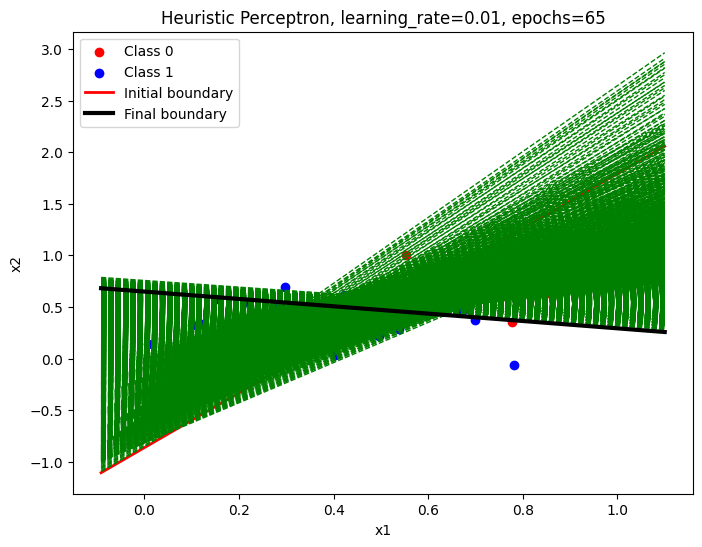

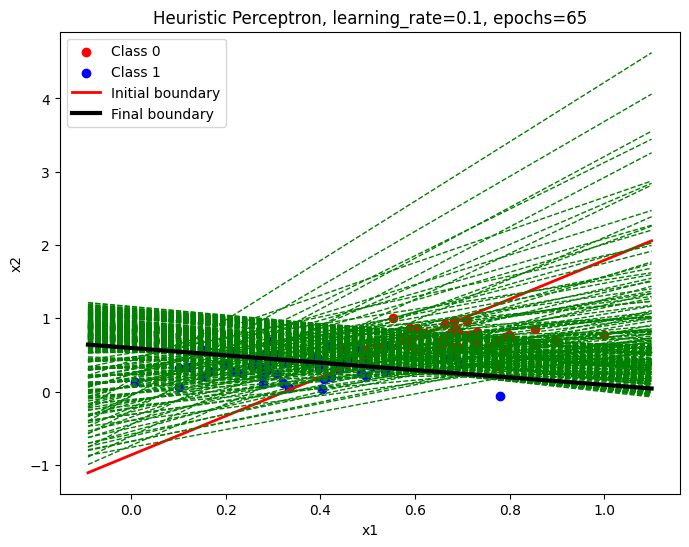

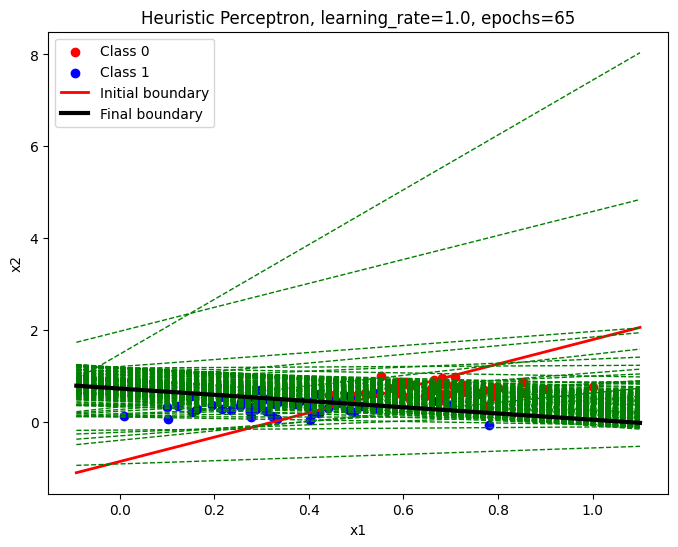

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("data.csv", header=None)
X = data.iloc[:, 0:2].values
y = data.iloc[:, 2].values

# Predict the class label
def predict(x, w, b):
    # Compute linear combination (w·x + b)
    if np.dot(w, x) + b >= 0:
        return 1
    else:
        return 0


# Train perceptron using heuristic update rule
def train_perceptron(X, y, learning_rate=0.1, epochs=65):
    np.random.seed(1)

    # Initialize weights and bias randomly
    w = np.random.randn(2)
    b = np.random.randn()

    # Store all decision boundaries for plotting later
    boundaries = [(w.copy(), b)]

    # Repeat training
    for epoch in range(epochs):

        # Loop through each data point
        for i in range(len(X)):

            # Predict class using current weights and bias
            y_hat = predict(X[i], w, b)

            # Update if the prediction is incorrect
            if y_hat != y[i]:

                # If true label is 1, move boundary toward this point
                if y[i] == 1:
                    b += learning_rate
                    w += learning_rate * X[i]

                # If true label is 0, move boundary away from this point
                else:
                    b -= learning_rate
                    w -= learning_rate * X[i]

                # Save updated boundary
                boundaries.append((w.copy(), b))

    return w, b, boundaries


# Plot decision boundary line from weights and bias
def plot_boundary(w, b, color, linestyle="-", linewidth=1, label=None):

    # Generate x values spanning the dataset range
    x_vals = np.linspace(X[:,0].min() - 0.1, X[:,0].max() + 0.1, 100)

    # Avoid division by zero
    if abs(w[1]) < 1e-8:
        return

    # Convert line equation:
    # w1*x + w2*y + b = 0  to  y = -(w1*x + b)/w2
    y_vals = -(w[0] * x_vals + b) / w[1]

    # Plot the decision boundary
    plt.plot(x_vals, y_vals, color=color, linestyle=linestyle,
             linewidth=linewidth, label=label)

def run_experiment(learning_rate, epochs=65):
    w, b, boundaries = train_perceptron(X, y, learning_rate, epochs)

    plt.figure(figsize=(8, 6))

    # Plot data from CSV
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color="red", label="Class 0")
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color="blue", label="Class 1")

    # Initial boundary
    plot_boundary(boundaries[0][0], boundaries[0][1],
                  color="red", linestyle="-", linewidth=2,
                  label="Initial boundary")

    # Intermediate boundaries
    for w_i, b_i in boundaries[1:-1]:
        plot_boundary(w_i, b_i, color="green", linestyle="--", linewidth=1)

    # Final boundary
    plot_boundary(boundaries[-1][0], boundaries[-1][1],
                  color="black", linestyle="-", linewidth=3,
                  label="Final boundary")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Heuristic Perceptron, learning_rate={learning_rate}, epochs={epochs}")
    plt.legend()
    plt.show()

# Play with learning rate
for lr in [0.01, 0.1, 1.0]:
    run_experiment(learning_rate=lr, epochs=65)

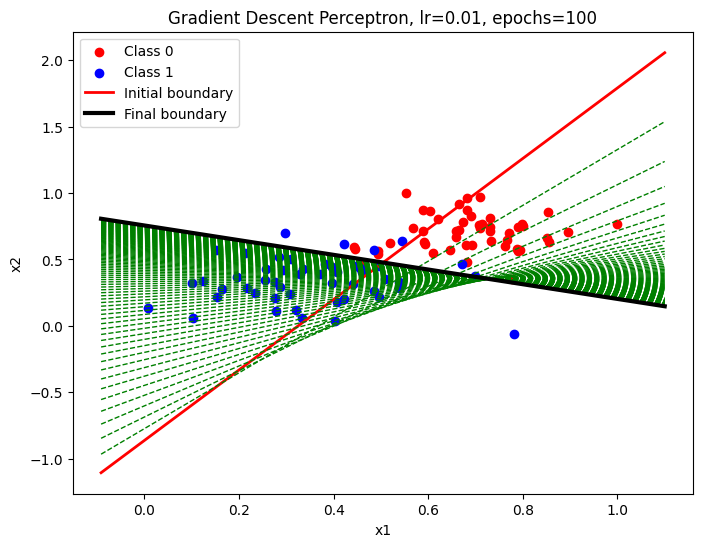

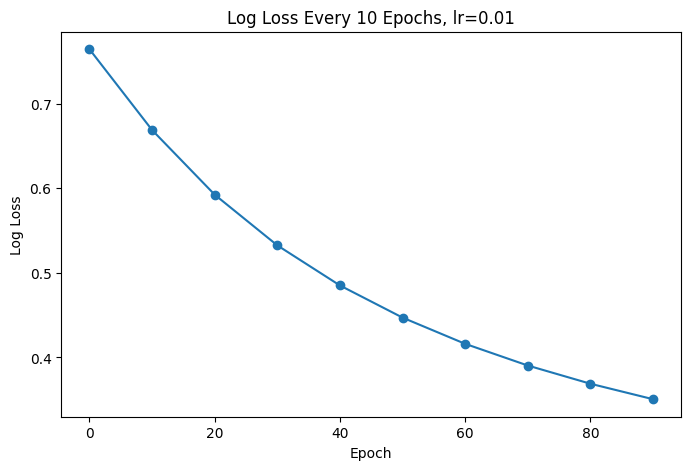

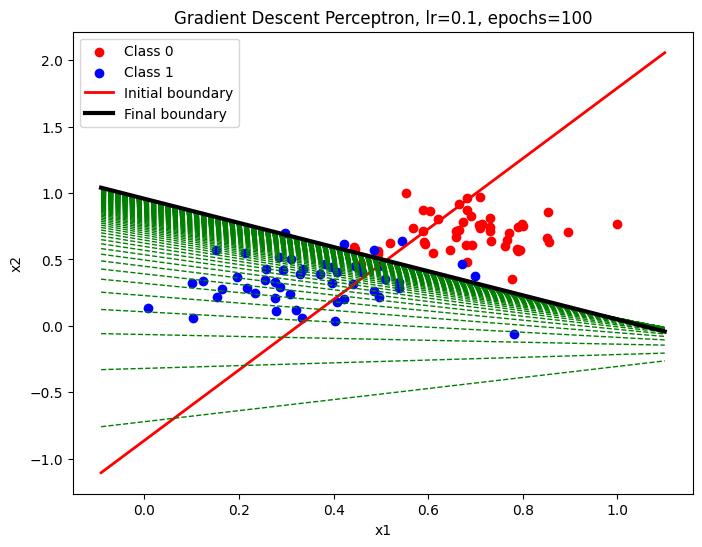

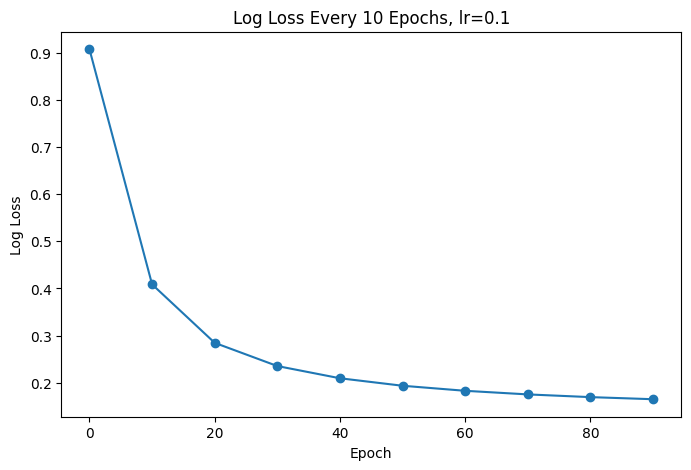

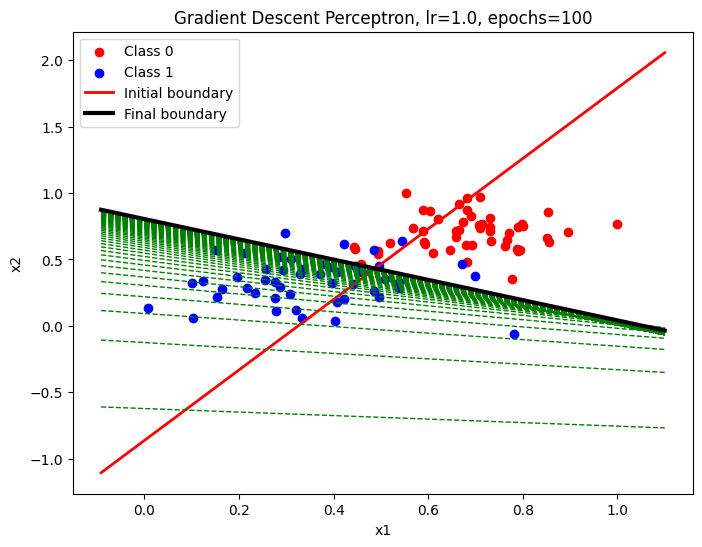

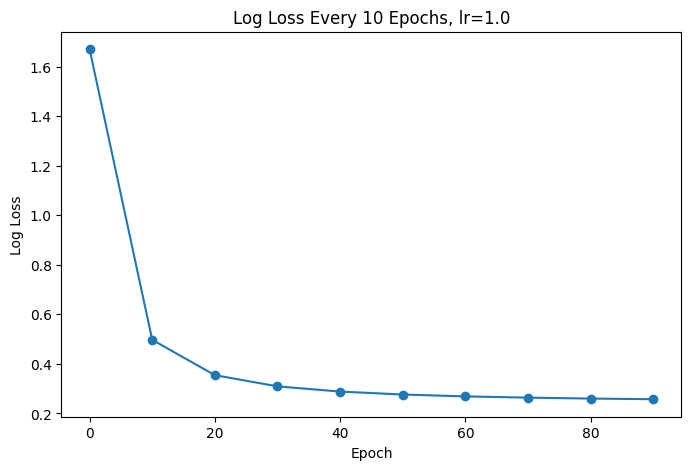

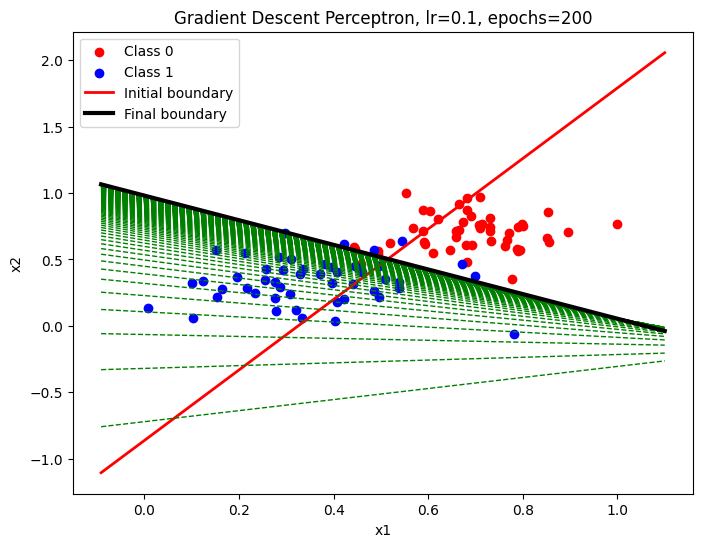

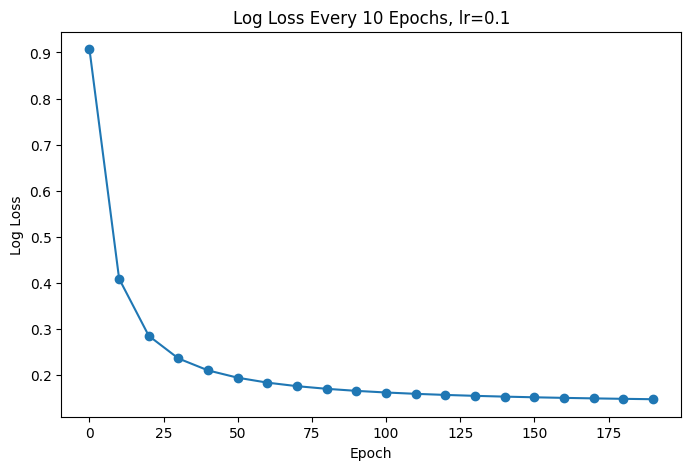

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("data.csv", header=None)
X = data.iloc[:, 0:2].values
y = data.iloc[:, 2].values

# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Compute log loss
def log_loss(y, y_hat):
    eps = 1e-15                              # avoid log(0)
    y_hat = np.clip(y_hat, eps, 1 - eps)     # keep predictions in safe range
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))


# Train using gradient descent
def train_gradient_descent_perceptron(X, y, learning_rate=0.1, epochs=100):

    np.random.seed(1)
    w = np.random.randn(2)
    b = np.random.randn()

    boundaries = [(w.copy(), b)]
    losses = []                             # store loss values
    loss_epochs = []                        # store epochs for loss plot

    for epoch in range(epochs):

        # Loop through each data point
        for i in range(len(X)):
            z = np.dot(w, X[i]) + b         # linear combination
            y_hat = sigmoid(z)              # predicted probability

            error = y[i] - y_hat            # prediction error

            b = b + learning_rate * error   # update bias
            w = w + learning_rate * error * X[i]  # update weights

        boundaries.append((w.copy(), b))    # save boundary after each epoch

        # Compute log loss every 10 epochs
        if epoch % 10 == 0:
            y_hat_all = sigmoid(np.dot(X, w) + b)
            loss = log_loss(y, y_hat_all)

            losses.append(loss)
            loss_epochs.append(epoch)

    return w, b, boundaries, losses, loss_epochs

def plot_boundary(w, b, color, linestyle="-", linewidth=1, label=None):
    x_vals = np.linspace(X[:,0].min() - 0.1, X[:,0].max() + 0.1, 100)

    if abs(w[1]) < 1e-8:
        return

    y_vals = -(w[0] * x_vals + b) / w[1]

    plt.plot(x_vals, y_vals, color=color, linestyle=linestyle,
             linewidth=linewidth, label=label)

def run_gd_experiment(learning_rate=0.1, epochs=100):
    w, b, boundaries, losses, loss_epochs = train_gradient_descent_perceptron(
        X, y, learning_rate, epochs
    )

    # Plot data and boundaries
    plt.figure(figsize=(8, 6))

    plt.scatter(X[y==0][:,0], X[y==0][:,1], color="red", label="Class 0")
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color="blue", label="Class 1")

    # Initial boundary
    plot_boundary(boundaries[0][0], boundaries[0][1],
                  color="red", linestyle="-", linewidth=2,
                  label="Initial boundary")

    # Intermediate boundaries
    for w_i, b_i in boundaries[1:-1]:
        plot_boundary(w_i, b_i,
                      color="green", linestyle="--", linewidth=1)

    # Final boundary
    plot_boundary(boundaries[-1][0], boundaries[-1][1],
                  color="black", linestyle="-", linewidth=3,
                  label="Final boundary")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Gradient Descent Perceptron, lr={learning_rate}, epochs={epochs}")
    plt.legend()
    plt.show()

    # Plot log loss
    plt.figure(figsize=(8, 5))
    plt.plot(loss_epochs, losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Log Loss")
    plt.title(f"Log Loss Every 10 Epochs, lr={learning_rate}")
    plt.show()

# Play with learning rate and number of epochs
experiments = [(0.01, 100), (0.1, 100), (1.0, 100), (0.1, 200)]

for lr, epochs in experiments:
    run_gd_experiment(learning_rate=lr, epochs=epochs)